# Fase IBM — Validação do VQR em Hardware Quântico Real (IBM Quantum)

**Objetivo:** executar a *inferência* do VQR (AngleEmbedding) — com parâmetros treinados no simulador — em três condições e compará-las:
1. **Simulador exato** (`default.qubit`)
2. **Backend ruidoso local** (`FakeBrisbane`) — reproduz o ruído do hardware sem gastar tempo de QPU
3. **Hardware real IBM** (backend menos ocupado)

**Regras de ouro (conta gratuita = ~10 min de QPU/mês):**
- **Não se treina em hardware.** Aqui só rodamos inferência com pesos já treinados.
- **Depure primeiro no `FakeBrisbane`.** Só ative `RUN_ON_HARDWARE = True` depois que tudo rodar no fake.
- Os 10 min são **tempo de execução na QPU** (não a fila). Um job pequeno de ~25 circuitos rasos gasta segundos.

**Como usar:** rode as células 1–9 (treino + simulador + fake). Confira a figura do fake. Depois cole seu token na célula de hardware, ponha `RUN_ON_HARDWARE = True` e rode a célula de hardware. Kernel: `qml_dengue`.

In [1]:
# Dependencias para hardware IBM — instala se necessario (idempotente).
# Necessario apenas para FakeBrisbane e para a execucao em hardware real.
%pip install -q pennylane-qiskit qiskit-ibm-runtime
print("[OK] pacotes verificados. Se ACABOU de instalar agora, reinicie o kernel e rode tudo de novo.")

Note: you may need to restart the kernel to use updated packages.
[OK] pacotes verificados. Se ACABOU de instalar agora, reinicie o kernel e rode tudo de novo.


In [2]:
import warnings; warnings.filterwarnings("ignore")
import os, sys, json, time, functools
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ─────────────────────────── CONFIGURACAO ───────────────────────────
RUN_ON_HARDWARE = True           # <-- deixe False ate validar no ruido/fake
IBM_TOKEN       = ""              # <-- cole aqui a API KEY da IBM Quantum (a chave secreta, entre aspas)
IBM_INSTANCE    = ""              # <-- (nova IBM Quantum Platform) cole o CRN da instancia, se sua conta exigir
N_QUBITS   = 6
N_LAYERS   = 4
N_EPOCHS   = 80
LR         = 0.01
PATIENCE   = 15
N_SEMANAS  = 25                  # nº de semanas de C2 a avaliar no hardware
SHOTS      = 2048
SEED       = 42
np.random.seed(SEED)
print(f"PennyLane {qml.__version__} | RUN_ON_HARDWARE={RUN_ON_HARDWARE} | shots={SHOTS}")

PennyLane 0.42.3 | RUN_ON_HARDWARE=True | shots=2048


In [3]:
# ── Dados: cenario C2 (corte out/2023, teste = surto de 2024) ──
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
sys.path.insert(0, os.path.abspath(".."))
from feature_engineering import construir_features, splits_validacao

with open(os.path.join(REPO_ROOT, "data", "dados_dengue_df_real.json"), encoding="utf-8") as f:
    dados = json.load(f)
dataset = construir_features(dados, n_lags=4)
splits  = splits_validacao(dataset)

C2 = splits[1]["treino"], splits[1]["teste"]
X_tr = np.array(C2[0]["X"]); y_tr = np.array(C2[0]["y"])
X_te = np.array(C2[1]["X"]); y_te = np.array(C2[1]["y"])
print(f"C2 treino={len(X_tr)} | teste={len(X_te)} | pico_teste={y_te.max():.0f}")

# Escala das 6 primeiras features para [0.01, pi] (mesmo protocolo do Fase1)
sc_feat = MinMaxScaler(feature_range=(0.01, np.pi))
Xtr6 = sc_feat.fit_transform(X_tr[:, :N_QUBITS])
Xte6 = sc_feat.transform(X_te[:, :N_QUBITS])

C2 treino=88 | teste=91 | pico_teste=25714


In [4]:
# ── Circuito do VQR: AngleEmbedding + SEL + observavel GLOBAL Z0..Z5 ──
OBS = functools.reduce(lambda a, b: a @ b, [qml.PauliZ(i) for i in range(N_QUBITS)])

def make_circuit(dev):
    @qml.qnode(dev)
    def circ(x, W):
        qml.AngleEmbedding(x[:N_QUBITS], wires=range(N_QUBITS), rotation="Y")
        qml.StronglyEntanglingLayers(W, wires=range(N_QUBITS))
        return qml.expval(OBS)
    return circ

# Device de treino (usa lightning.qubit se disponivel)
try:
    import pennylane_lightning  # noqa
    dev_train = qml.device("lightning.qubit", wires=N_QUBITS)
except ImportError:
    dev_train = qml.device("default.qubit", wires=N_QUBITS)
print(f"Device de treino: {dev_train.name}")

Device de treino: lightning.qubit


In [5]:
# ── Treino de UMA replica do VQR em C2 (simulador) ──
from copy import deepcopy
circ_train = make_circuit(dev_train)

y_log = np.log1p(y_tr).astype(float)
mu_y, sig_y = y_log.mean(), y_log.std() + 1e-8
y_norm = (y_log - mu_y) / sig_y
Xb = pnp.array(Xtr6, requires_grad=False)
yb = pnp.array(y_norm, requires_grad=False)

rng = np.random.RandomState(SEED)
W  = pnp.array(rng.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS, 3)) * 0.01, requires_grad=True)
sc = pnp.array(rng.uniform(0.5, 1.5), requires_grad=True)
bi = pnp.array(0.0, requires_grad=True)
opt = qml.AdamOptimizer(LR)

best_loss, best = float("inf"), None; patc = 0; t0 = time.time()
for ep in range(N_EPOCHS):
    def cost(W_, sc_, bi_):
        preds = pnp.stack([circ_train(Xb[i], W_) * sc_ + bi_ for i in range(len(Xb))])
        return pnp.mean((preds - yb) ** 2)
    (W, sc, bi), loss = opt.step_and_cost(cost, W, sc, bi)
    lv = float(loss)
    if lv < best_loss:
        best_loss, best, patc = lv, (deepcopy(W.numpy()), float(sc), float(bi)), 0
    else:
        patc += 1
        if patc >= PATIENCE: break
    if ep % 10 == 0:
        print(f"  epoch {ep:3d} | loss={lv:.4f}")

W_star = pnp.array(best[0], requires_grad=False); sc_star, bi_star = best[1], best[2]
print(f"Treino concluido em {time.time()-t0:.0f}s | melhor loss={best_loss:.4f}")

  epoch   0 | loss=1.1778
  epoch  10 | loss=1.0823
  epoch  20 | loss=1.0055
  epoch  30 | loss=0.9517
  epoch  40 | loss=0.8959
  epoch  50 | loss=0.8196
  epoch  60 | loss=0.7329
  epoch  70 | loss=0.6476
Treino concluido em 120s | melhor loss=0.5697


In [6]:
# ── Funcoes de predicao (para qualquer device OU circuito ja construido) ──
def predizer_circ(circ, X6, W, sc, bi, mu_y, sig_y, label=""):
    raw, t0 = [], time.time()
    for i, x in enumerate(X6):
        val = float(circ(pnp.array(x, requires_grad=False), W))
        raw.append(val * sc + bi)
        if label and (i + 1) % 10 == 0:
            print(f"    [{label}] {i+1}/{len(X6)}")
    preds = np.maximum(np.expm1(np.array(raw) * sig_y + mu_y), 0.0)
    if label:
        print(f"  [{label}] {len(X6)} circuitos em {time.time()-t0:.1f}s")
    return preds

def predizer(dev, X6, W, sc, bi, mu_y, sig_y, label=""):
    return predizer_circ(make_circuit(dev), X6, W, sc, bi, mu_y, sig_y, label)

def avaliar(y, p):
    return {"R2": r2_score(y, p), "RMSE": float(np.sqrt(mean_squared_error(y, p))),
            "MAE": float(mean_absolute_error(y, p))}

In [7]:
# ── Seleciona ~25 semanas de C2 (do vale ao pico) ──
idx_sel = np.unique(np.linspace(0, len(Xte6) - 1, N_SEMANAS).astype(int))
Xsel = Xte6[idx_sel]; ysel = y_te[idx_sel]
print(f"Semanas selecionadas: {len(idx_sel)} | pico no subconjunto={ysel.max():.0f}")

# 1) Simulador exato
dev_sim = qml.device("default.qubit", wires=N_QUBITS)
pred_sim = predizer(dev_sim, Xsel, W_star, sc_star, bi_star, mu_y, sig_y, label="simulador")
print("Simulador:", avaliar(ysel, pred_sim))

Semanas selecionadas: 25 | pico no subconjunto=23969
    [simulador] 10/25
    [simulador] 20/25
  [simulador] 25 circuitos em 0.5s
Simulador: {'R2': -0.14339205103814257, 'RMSE': 7466.884380539751, 'MAE': 3429.2557987527857}


## Dry-run: backend ruidoso local (FakeBrisbane)

Reproduz o ruido do `ibm_brisbane` **localmente**, sem gastar tempo de QPU. Se a celula abaixo rodar e a figura fizer sentido, o pipeline de hardware esta correto.

In [8]:
# ── Comparacao com ruido: tenta FakeBrisbane (IBM); se falhar, usa default.mixed (nativo) ──
pred_fake, fake_label = None, None
P_DEPOL = 0.01   # taxa de depolarizacao do plano B (ordem de grandeza NISQ)
try:
    from qiskit_ibm_runtime.fake_provider import FakeBrisbane
    fake = FakeBrisbane()
    dev_fake = qml.device("qiskit.remote", wires=N_QUBITS, backend=fake, shots=SHOTS)
    pred_fake = predizer(dev_fake, Xsel, W_star, sc_star, bi_star, mu_y, sig_y, label="fake-IBM")
    fake_label = "Fake IBM (FakeBrisbane)"
except Exception as e:
    print("[AVISO] FakeBrisbane indisponivel (qiskit nao instalado/incompativel ou kernel nao reiniciado).")
    print("        Plano B: ruido nativo do PennyLane (default.mixed + canal de depolarizacao).")
    print("        Detalhe:", repr(e))
    dev_mixed = qml.device("default.mixed", wires=N_QUBITS)
    circ_noisy = qml.transforms.insert(make_circuit(dev_mixed),
                                       qml.DepolarizingChannel, P_DEPOL, position="all")
    pred_fake = predizer_circ(circ_noisy, Xsel, W_star, sc_star, bi_star, mu_y, sig_y, label="ruido")
    fake_label = f"Ruido nativo (default.mixed, depol p={P_DEPOL})"
print(f"{fake_label}:", avaliar(ysel, pred_fake))

    [fake-IBM] 10/25
    [fake-IBM] 20/25
  [fake-IBM] 25 circuitos em 94.1s
Fake IBM (FakeBrisbane): {'R2': -0.14473727169708184, 'RMSE': 7471.275549098418, 'MAE': 3513.255490343116}


## Hardware real IBM Quantum

Cole seu token na celula de configuracao (`IBM_TOKEN`) e ponha `RUN_ON_HARDWARE = True`.
A celula abaixo envia UM lote de ~25 circuitos rasos ao backend menos ocupado.

> **Atencao com a autenticacao:** o canal/instancia dependem da sua conta. A forma classica e
> `QiskitRuntimeService(channel="ibm_quantum", token=IBM_TOKEN)`. Se sua conta ja migrou para a
> nova IBM Quantum Platform, use `channel="ibm_quantum_platform"` com o parametro `instance` (CRN),
> conforme a documentacao atual da IBM. Salvar a conta uma vez com
> `QiskitRuntimeService.save_account(...)` evita repetir o token.

In [9]:
# ── Execucao em hardware real (guardada por RUN_ON_HARDWARE) ──
pred_hw, backend_nome = None, None
if RUN_ON_HARDWARE:
    assert IBM_TOKEN, "Cole a API KEY da IBM em IBM_TOKEN (celula de configuracao, entre aspas)."
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(channel="ibm_cloud", token=IBM_TOKEN, instance=IBM_INSTANCE)
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=N_QUBITS)
    backend_nome = backend.name
    print(f"Backend selecionado: {backend_nome}")

    dev_hw = qml.device("qiskit.remote", wires=N_QUBITS, backend=backend, shots=SHOTS)
    t0 = time.time()
    pred_hw = predizer(dev_hw, Xsel, W_star, sc_star, bi_star, mu_y, sig_y, label="hardware")
    print(f"Hardware ({backend_nome}):", avaliar(ysel, pred_hw))
    print(f"Tempo total do job: {time.time()-t0:.0f}s (wall-clock, inclui fila)")
else:
    print("RUN_ON_HARDWARE=False — pulando execucao real. Ative apos validar no ruido/fake.")

Backend selecionado: ibm_fez
    [hardware] 10/25
    [hardware] 20/25
  [hardware] 25 circuitos em 701.0s
Hardware (ibm_fez): {'R2': -0.14574970169735169, 'RMSE': 7474.578696449334, 'MAE': 3485.1659141879713}
Tempo total do job: 701s (wall-clock, inclui fila)


In [10]:
# ── Tabela comparativa ──
linhas = [("Simulador (default.qubit)", pred_sim)]
if pred_fake is not None: linhas.append((fake_label, pred_fake))
if pred_hw   is not None: linhas.append((f"Hardware ({backend_nome})", pred_hw))

print(f"{'Condicao':<40}{'R2':>10}{'RMSE':>12}{'MAE':>12}")
print("-" * 74)
resumo = {}
for nome, p in linhas:
    m = avaliar(ysel, p)
    resumo[nome] = m
    print(f"{nome:<40}{m['R2']:>10.4f}{m['RMSE']:>12.1f}{m['MAE']:>12.1f}")

Condicao                                        R2        RMSE         MAE
--------------------------------------------------------------------------
Simulador (default.qubit)                  -0.1434      7466.9      3429.3
Fake IBM (FakeBrisbane)                    -0.1447      7471.3      3513.3
Hardware (ibm_fez)                         -0.1457      7474.6      3485.2


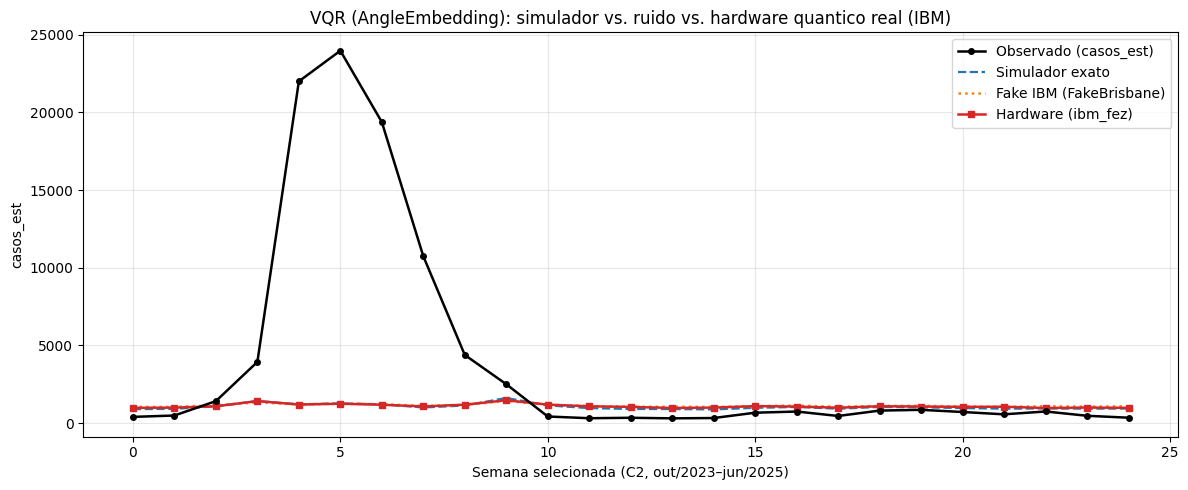

[SALVO] fig_ibm_hardware_vqr.png


In [11]:
# ── Figura: observado vs simulador vs ruido vs hardware ──
x = np.arange(len(idx_sel))
plt.figure(figsize=(12, 5))
plt.plot(x, ysel, "k-o", lw=1.8, ms=4, label="Observado (casos_est)", zorder=6)
plt.plot(x, pred_sim, "--", color="tab:blue", lw=1.6, label="Simulador exato")
if pred_fake is not None:
    plt.plot(x, pred_fake, ":", color="tab:orange", lw=1.8, label=fake_label)
if pred_hw is not None:
    plt.plot(x, pred_hw, "-", color="tab:red", lw=1.8, marker="s", ms=4,
             label=f"Hardware ({backend_nome})")
plt.xlabel("Semana selecionada (C2, out/2023–jun/2025)")
plt.ylabel("casos_est")
plt.title("VQR (AngleEmbedding): simulador vs. ruido vs. hardware quantico real (IBM)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("fig_ibm_hardware_vqr.png", dpi=150, bbox_inches="tight")
plt.show()
print("[SALVO] fig_ibm_hardware_vqr.png")

In [12]:
# ── Salva resultados ──
saida = {
    "modelo": "VQR_AngleEmbedding", "cenario": "C2",
    "n_semanas": int(len(idx_sel)), "shots": SHOTS,
    "backend": backend_nome, "executado_em_hardware": bool(RUN_ON_HARDWARE),
    "metricas": {k: {kk: round(float(vv), 4) for kk, vv in v.items()} for k, v in resumo.items()},
    "indices_semanas": [int(i) for i in idx_sel],
}
with open("fase_ibm_hardware_vqr_resultados.json", "w", encoding="utf-8") as f:
    json.dump(saida, f, indent=2, ensure_ascii=False)
print("[SALVO] fase_ibm_hardware_vqr_resultados.json")
print(json.dumps(saida["metricas"], indent=2, ensure_ascii=False))

[SALVO] fase_ibm_hardware_vqr_resultados.json
{
  "Simulador (default.qubit)": {
    "R2": -0.1434,
    "RMSE": 7466.8844,
    "MAE": 3429.2558
  },
  "Fake IBM (FakeBrisbane)": {
    "R2": -0.1447,
    "RMSE": 7471.2755,
    "MAE": 3513.2555
  },
  "Hardware (ibm_fez)": {
    "R2": -0.1457,
    "RMSE": 7474.5787,
    "MAE": 3485.1659
  }
}
